# Fase 1 — EDA: desbalance de clases

Tercera tarea de la Fase 1 (ver `FASES.md`): cuantificar cuántos positivos/negativos de Chagas hay por dataset. Esto determina la estrategia de entrenamiento en fases posteriores (class weights, oversampling, qué métrica usar — accuracy es engañoso con este nivel de desbalance).

Importante: no todos los positivos/negativos tienen el mismo origen. La columna `confianza` distingue:
- **strong**: SaMi-Trop, confirmado por serología (ver nota en memoria del proyecto — 100% positivo por diseño de la cohorte, no una muestra poblacional).
- **weak**: CODE-15%, autorreportado por el paciente/formulario clínico, no serología.
- **negativo-presunto**: PTB-XL, negativo por presunción (población alemana, no endémica de Chagas), no por test negativo.

Mezclar estos niveles de confianza como si fueran igual de confiables sería un error — el desbalance hay que leerlo dataset por dataset, no solo en agregado.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np

from eda_utils import cargar_metadata

meta = cargar_metadata()
DATASETS = ["code15", "samitrop", "ptbxl"]

## Conteo por dataset

In [2]:
tabla = meta.groupby(["dataset", "confianza"]).agg(
    n=("record_id", "count"),
    positivos=("chagas_label", "sum"),
)
tabla["% positivos"] = (tabla["positivos"] / tabla["n"] * 100).round(2)
tabla

,,n,positivos,% positivos
dataset,confianza,,,
code15,weak,343424,6561,1.91
ptbxl,negativo-presunto,21799,0,0.00
samitrop,strong,1631,1631,100.00


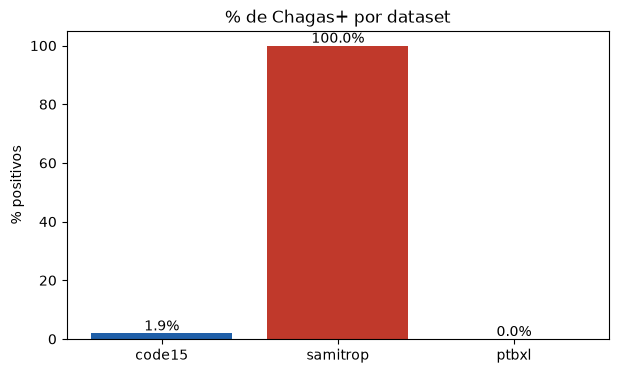

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
pct_positivos = [meta.loc[meta["dataset"] == d, "chagas_label"].mean() * 100 for d in DATASETS]
ax.bar(DATASETS, pct_positivos, color=["#1f5fa8", "#c0392b", "#2c8a4b"])
for i, v in enumerate(pct_positivos):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylabel("% positivos")
ax.set_ylim(0, 105)
ax.set_title("% de Chagas+ por dataset")
plt.show()

## Desbalance agregado (los 3 datasets combinados)

Relevante solo si en Fase 2 se entrena con los 3 datasets mezclados sin ponderar por origen. Como CODE-15% domina en volumen (343.424 de 366.854 registros), el agregado queda dominado por su ~2% de prevalencia — SaMi-Trop y PTB-XL, pese a ser 100%/0% positivos, pesan poco en el total simplemente por ser chicos.

In [4]:
n_total = len(meta)
n_pos = int(meta["chagas_label"].sum())
print(f"Total: {n_total} registros")
print(f"Positivos: {n_pos} ({n_pos / n_total * 100:.2f}%)")
print(f"Negativos: {n_total - n_pos} ({(n_total - n_pos) / n_total * 100:.2f}%)")
print(f"Ratio negativo:positivo = {(n_total - n_pos) / n_pos:.1f}:1")

Total: 366854 registros
Positivos: 8192 (2.23%)
Negativos: 358662 (97.77%)
Ratio negativo:positivo = 43.8:1


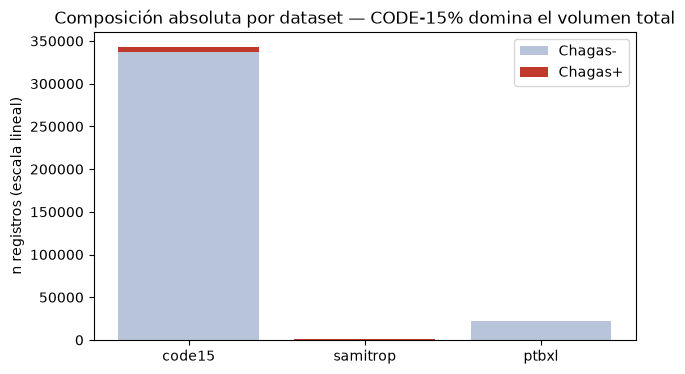

In [5]:
composicion = meta.groupby(["dataset", "chagas_label"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(DATASETS, [composicion.loc[d, False] for d in DATASETS], label="Chagas-", color="#b8c4d9")
ax.bar(
    DATASETS,
    [composicion.loc[d, True] for d in DATASETS],
    bottom=[composicion.loc[d, False] for d in DATASETS],
    label="Chagas+",
    color="#c0392b",
)
ax.set_ylabel("n registros (escala lineal)")
ax.set_title("Composición absoluta por dataset — CODE-15% domina el volumen total")
ax.legend()
plt.show()